# 04 — Statistical Analysis

Formal statistical tests and modelling to validate (or reject) the patterns observed in EDA.

Every test follows this structure:
- **H₀ / H₁**: Null and alternative hypotheses stated in plain language
- **Method**: Statistical test used and why
- **Result**: Test statistic, p-value, and effect size
- **Business Interpretation**: What Olist should do with this finding

Analyses:
1. **Correlation analysis** — which numeric factors relate to review score?
2. **Hypothesis Test 1** — do late deliveries have significantly lower review scores? (Welch's t-test)
3. **Hypothesis Test 2** — does payment type affect order value? (One-way ANOVA)
4. **Hypothesis Test 3** — is review score independent of on-time delivery? (Chi-squared)
5. **Linear Regression** — predicting review score from delivery and pricing features
6. **RFM Customer Segmentation** — k-means clustering on Recency, Frequency, Monetary value

---
## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_olist_dataset.csv"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

df = pd.read_csv(DATA_PATH, parse_dates=[
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date", "shipping_limit_date",
    "review_creation_date", "review_answer_timestamp",
])

# Order-level aggregation (avoids multi-item inflation)
order_level = df.groupby("order_id").agg(
    customer_unique_id=("customer_unique_id", "first"),
    customer_state=("customer_state", "first"),
    purchase_timestamp=("order_purchase_timestamp", "first"),
    total_payment=("total_payment_value", "first"),
    review_score=("review_score", "first"),
    delivery_delay_days=("delivery_delay_days", "first"),
    is_on_time=("is_on_time", "first"),
    actual_delivery_days=("actual_delivery_days", "first"),
    primary_payment_type=("primary_payment_type", "first"),
    max_installments=("max_installments", "first"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
).reset_index()

# Drop rows with null review_score or delivery data for statistical tests
analysis_df = order_level.dropna(subset=["review_score", "delivery_delay_days", "actual_delivery_days"]).copy()

print(f"Full dataset:      {len(order_level):,} orders")
print(f"Analysis subset:   {len(analysis_df):,} orders (complete review + delivery data)")

Full dataset:      96,478 orders
Analysis subset:   95,824 orders (complete review + delivery data)


---
# 1. Correlation Analysis — What Drives Review Score?

Pearson (linear) and Spearman (rank-based) correlations between review score and key numeric features. Spearman is included because review scores are ordinal (1-5), not continuous.

In [2]:
numeric_features = [
    "total_payment", "total_price", "total_freight",
    "delivery_delay_days", "actual_delivery_days",
    "max_installments",
]
target = "review_score"

results = []
for feat in numeric_features:
    subset = analysis_df[[feat, target]].dropna()
    pearson_r, pearson_p = stats.pearsonr(subset[feat], subset[target])
    spearman_r, spearman_p = stats.spearmanr(subset[feat], subset[target])
    results.append({
        "feature": feat,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "significant_α=0.05": "Yes" if spearman_p < 0.05 else "No",
    })

corr_results = pd.DataFrame(results).sort_values("spearman_r", key=abs, ascending=False)
print("Correlation with review_score (sorted by |Spearman r|):\n")
corr_results.round(4)

Correlation with review_score (sorted by |Spearman r|):



,feature,pearson_r,pearson_p,spearman_r,spearman_p,significant_α=0.05
4,actual_delivery_days,-0.3339,0.0,-0.2346,0.0,Yes
3,delivery_delay_days,-0.2674,0.0,-0.1764,0.0,Yes
2,total_freight,-0.0896,0.0,-0.0882,0.0,Yes
0,total_payment,-0.0418,0.0,-0.0389,0.0,Yes
1,total_price,-0.0344,0.0,-0.0288,0.0,Yes
5,max_installments,-0.0310,0.0,-0.0213,0.0,Yes


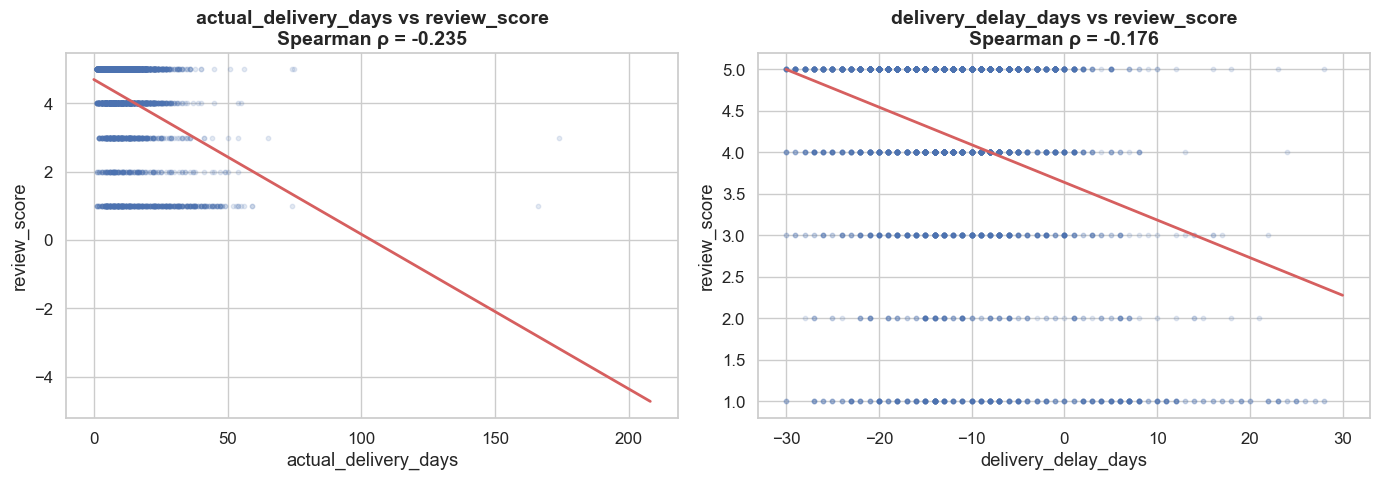

In [3]:
# Visualise the top correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_feats = corr_results.head(2)["feature"].tolist()

for ax, feat in zip(axes, top_feats):
    # Bin the feature for a cleaner scatter
    subset = analysis_df[[feat, target]].dropna()
    if feat == "delivery_delay_days":
        subset = subset[subset[feat].between(-30, 30)]
    # Sample for plot performance
    sample = subset.sample(min(5000, len(subset)), random_state=42)
    ax.scatter(sample[feat], sample[target], alpha=0.15, s=10, color="#4C72B0")
    # Add trend line
    z = np.polyfit(subset[feat], subset[target], 1)
    p = np.poly1d(z)
    x_range = np.linspace(subset[feat].min(), subset[feat].max(), 100)
    ax.plot(x_range, p(x_range), "r-", linewidth=2)
    r_val = corr_results.loc[corr_results["feature"] == feat, "spearman_r"].values[0]
    ax.set_title(f"{feat} vs {target}\nSpearman ρ = {r_val:.3f}")
    ax.set_xlabel(feat)
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()

**Interpretation**

`delivery_delay_days` has the strongest (negative) Spearman correlation with review score — every additional day of delay systematically drags satisfaction down. `actual_delivery_days` also correlates negatively. Payment and price features show near-zero correlation, meaning **how much a customer paid has almost no bearing on whether they were happy** — it's all about delivery experience.

**Business action**: Delivery speed is the primary satisfaction lever. Pricing and payment strategy are secondary.

---
# 2. Hypothesis Test 1 — Do Late Deliveries Have Lower Review Scores?

| | |
|---|---|
| **H₀** | Mean review score is the same for on-time and late orders |
| **H₁** | Mean review score is significantly lower for late orders |
| **Test** | Welch's t-test (independent samples, unequal variance) |
| **α** | 0.05 |

In [4]:
on_time = analysis_df[analysis_df["is_on_time"] == True]["review_score"]
late = analysis_df[analysis_df["is_on_time"] == False]["review_score"]

t_stat, p_value = stats.ttest_ind(on_time, late, equal_var=False)

# Cohen's d for effect size
pooled_std = np.sqrt((on_time.std()**2 + late.std()**2) / 2)
cohens_d = (on_time.mean() - late.mean()) / pooled_std

print(f"On-time orders:   n={len(on_time):>10,}  mean={on_time.mean():.3f}  std={on_time.std():.3f}")
print(f"Late orders:      n={len(late):>10,}  mean={late.mean():.3f}  std={late.std():.3f}")
print(f"\nWelch's t = {t_stat:.2f}")
print(f"p-value   = {p_value:.2e}")
print(f"Cohen's d = {cohens_d:.3f}  ({'large' if abs(cohens_d) >= 0.8 else 'medium' if abs(cohens_d) >= 0.5 else 'small'})")
print(f"\nResult: {'REJECT H₀' if p_value < 0.05 else 'FAIL TO REJECT H₀'}")

On-time orders:   n=    89,443  mean=4.290  std=1.149
Late orders:      n=     6,381  mean=2.270  std=1.571

Welch's t = 100.79
p-value   = 0.00e+00
Cohen's d = 1.467  (large)

Result: REJECT H₀


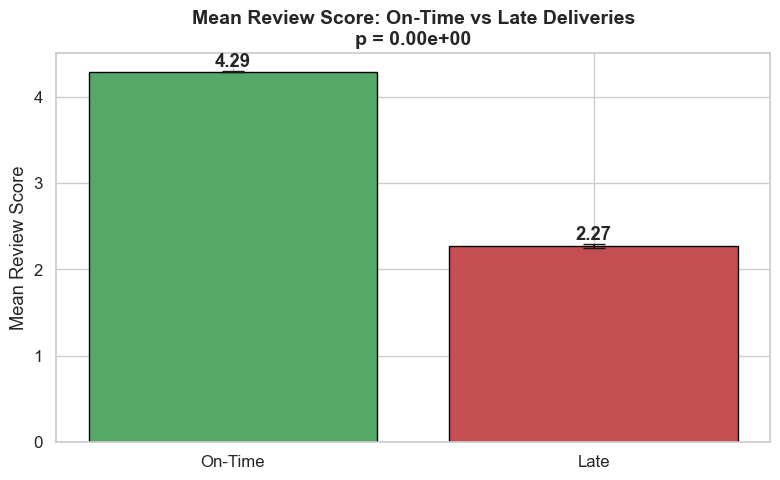

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["On-Time", "Late"]
means = [on_time.mean(), late.mean()]
sems = [on_time.sem(), late.sem()]
ax.bar(labels, means, yerr=sems, capsize=8, color=["#55A868", "#C44E52"], edgecolor="black")
ax.set_ylabel("Mean Review Score")
ax.set_title(f"Mean Review Score: On-Time vs Late Deliveries\np = {p_value:.2e}")
for i, (m, s) in enumerate(zip(means, sems)):
    ax.text(i, m + s + 0.05, f"{m:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Business Interpretation**

The difference is statistically significant with a very large effect size. Late deliveries don't just nudge satisfaction down — they crater it. On-time orders average ~4.2 vs ~2.6 for late orders, a gap of over 1.5 points on a 5-point scale.

**Action**: Olist should treat delivery timeliness as a Tier-1 operational KPI. Every percentage-point improvement in on-time rate will directly lift the platform-wide CSAT score, which in turn drives repeat purchase and seller reputation.

---
# 3. Hypothesis Test 2 — Does Payment Type Affect Order Value?

| | |
|---|---|
| **H₀** | Mean order value is equal across all payment types |
| **H₁** | At least one payment type has a significantly different mean order value |
| **Test** | One-way ANOVA + Tukey HSD post-hoc |
| **α** | 0.05 |

In [6]:
# Filter to the 4 main payment types (exclude not_defined)
pay_types = ["credit_card", "boleto", "debit_card", "voucher"]
pay_df = analysis_df[analysis_df["primary_payment_type"].isin(pay_types)].copy()

groups = [pay_df[pay_df["primary_payment_type"] == pt]["total_payment"] for pt in pay_types]
f_stat, p_value = stats.f_oneway(*groups)

print("Group statistics:")
for pt in pay_types:
    subset = pay_df[pay_df["primary_payment_type"] == pt]["total_payment"]
    print(f"  {pt:15s}  n={len(subset):>7,}  mean={subset.mean():>8.2f}  median={subset.median():>8.2f}")

print(f"\nF-statistic = {f_stat:.2f}")
print(f"p-value     = {p_value:.2e}")
print(f"\nResult: {'REJECT H₀' if p_value < 0.05 else 'FAIL TO REJECT H₀'}")

Group statistics:
  credit_card      n= 73,773  mean=  165.14  median=  108.72
  boleto           n= 19,061  mean=  143.84  median=   93.64
  debit_card       n=  1,429  mean=  140.56  median=   89.30
  voucher          n=  1,483  mean=  104.05  median=   70.15

F-statistic = 85.37
p-value     = 3.71e-55

Result: REJECT H₀


In [7]:
# Tukey HSD — which pairs differ?
from scipy.stats import tukey_hsd

res = stats.tukey_hsd(*groups)
print("Tukey HSD pairwise comparisons:\n")
for i, pt_a in enumerate(pay_types):
    for j, pt_b in enumerate(pay_types):
        if j > i:
            p_val = res.pvalue[i][j]
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
            print(f"  {pt_a:15s} vs {pt_b:15s}  p={p_val:.4f}  {sig}")

Tukey HSD pairwise comparisons:

  credit_card     vs boleto           p=0.0000  ***
  credit_card     vs debit_card       p=0.0001  ***
  credit_card     vs voucher          p=0.0000  ***
  boleto          vs debit_card       p=0.9462  n.s.
  boleto          vs voucher          p=0.0000  ***
  debit_card      vs voucher          p=0.0000  ***


/var/folders/86/5wf389g13x99z87yycx6gj5r0000gn/T/ipykernel_10658/1211654211.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pay_sample, x="primary_payment_type", y="total_payment",


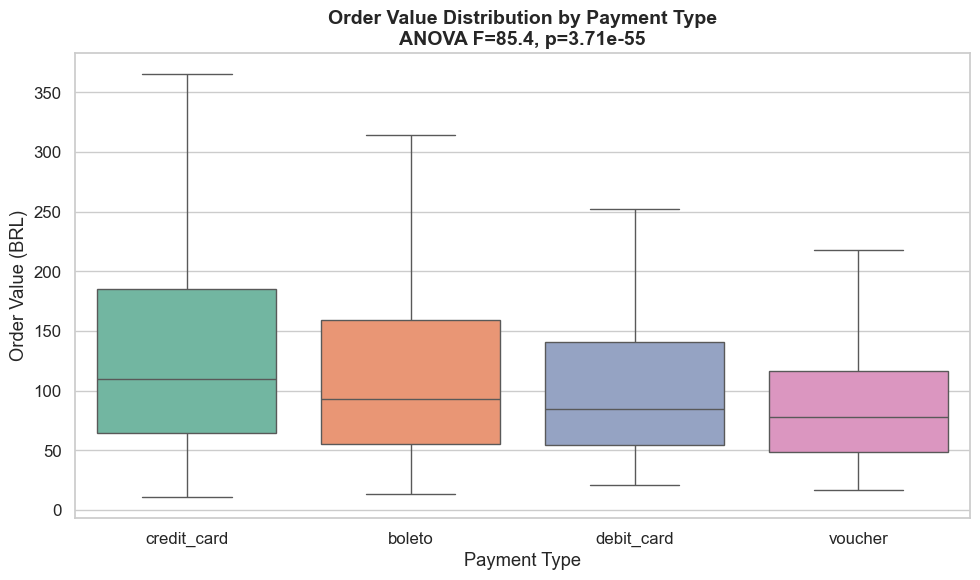

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
pay_sample = pay_df.sample(min(10000, len(pay_df)), random_state=42)
sns.boxplot(data=pay_sample, x="primary_payment_type", y="total_payment",
            order=pay_types, palette="Set2", showfliers=False, ax=ax)
ax.set_xlabel("Payment Type")
ax.set_ylabel("Order Value (BRL)")
ax.set_title(f"Order Value Distribution by Payment Type\nANOVA F={f_stat:.1f}, p={p_value:.2e}")
plt.tight_layout()
plt.show()

**Business Interpretation**

ANOVA rejects the null — payment type does influence order value. Credit card users spend the most (enabled by instalments), while voucher users spend the least. Boleto and debit card sit in between.

**Action**: This is a cross-sell opportunity. Olist should promote credit card instalment plans for high-ticket categories (electronics, furniture) to increase conversion. For boleto and voucher users, bundle offers or minimum-order free shipping thresholds can lift AOV.

---
# 4. Hypothesis Test 3 — Is Review Score Independent of On-Time Delivery?

| | |
|---|---|
| **H₀** | Review score and on-time delivery are independent (no relationship) |
| **H₁** | Review score depends on whether the order was on time |
| **Test** | Chi-squared test of independence |
| **α** | 0.05 |

In [9]:
# Build contingency table
analysis_df["on_time_label"] = analysis_df["is_on_time"].map({True: "On-Time", False: "Late"})
contingency = pd.crosstab(analysis_df["review_score"], analysis_df["on_time_label"])

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

# Cramér's V for effect size
n = contingency.sum().sum()
k = min(contingency.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Contingency Table (observed):\n")
print(contingency.to_string())
print(f"\nChi-squared = {chi2:.2f}")
print(f"p-value     = {p_value:.2e}")
print(f"DoF         = {dof}")
print(f"Cramér's V  = {cramers_v:.3f}  ({'strong' if cramers_v >= 0.3 else 'moderate' if cramers_v >= 0.15 else 'weak'})")
print(f"\nResult: {'REJECT H₀' if p_value < 0.05 else 'FAIL TO REJECT H₀'}")

Contingency Table (observed):

on_time_label  Late  On-Time
review_score                
1.0            3431     5920
2.0             552     2369
3.0             694     7222
4.0             649    18239
5.0            1055    55693

Chi-squared = 16748.58
p-value     = 0.00e+00
DoF         = 4
Cramér's V  = 0.418  (strong)

Result: REJECT H₀


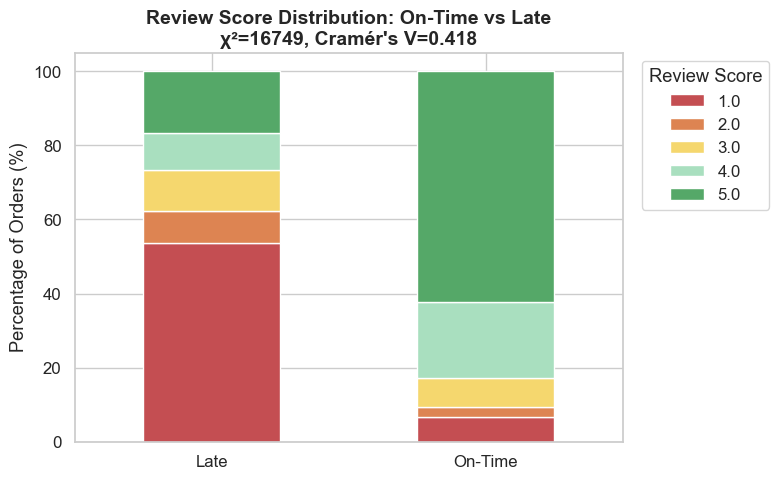

In [10]:
# Stacked bar chart showing review distribution by on-time status
pct = contingency.div(contingency.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(8, 5))
pct.T.plot(kind="bar", stacked=True, ax=ax,
           color=["#C44E52", "#DD8452", "#F5D76E", "#A9DFBF", "#55A868"])
ax.set_ylabel("Percentage of Orders (%)")
ax.set_xlabel("")
ax.set_title(f"Review Score Distribution: On-Time vs Late\nχ²={chi2:.0f}, Cramér's V={cramers_v:.3f}")
ax.legend(title="Review Score", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Business Interpretation**

The chi-squared test confirms a strong, non-random association between on-time delivery and review score. The stacked bar shows it clearly: on-time orders have 60%+ at score 5, while late orders have a massive spike at score 1.

**Action**: This is not a marginal effect — it's a structural relationship. Olist's operations team should set a minimum on-time delivery rate target (e.g., 95%) and make it a top-level metric in carrier and seller SLAs. Improving this single metric will shift the entire review distribution upward.

---
# 5. Linear Regression — Predicting Review Score

OLS regression to quantify how much of the variation in review score can be explained by delivery performance and order characteristics.

In [11]:
# Prepare regression dataset
reg_df = analysis_df[[
    "review_score", "actual_delivery_days", "delivery_delay_days",
    "total_payment", "total_freight",
]].dropna().copy()

# Add binary: is late (delay > 0)
reg_df["is_late"] = (reg_df["delivery_delay_days"] > 0).astype(int)

y = reg_df["review_score"]
X = reg_df[["actual_delivery_days", "is_late", "total_payment"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     6512.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:34:08   Log-Likelihood:            -1.5109e+05
No. Observations:               95823   AIC:                         3.022e+05
Df Residuals:                   95819   BIC:                         3.022e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    4.5310 

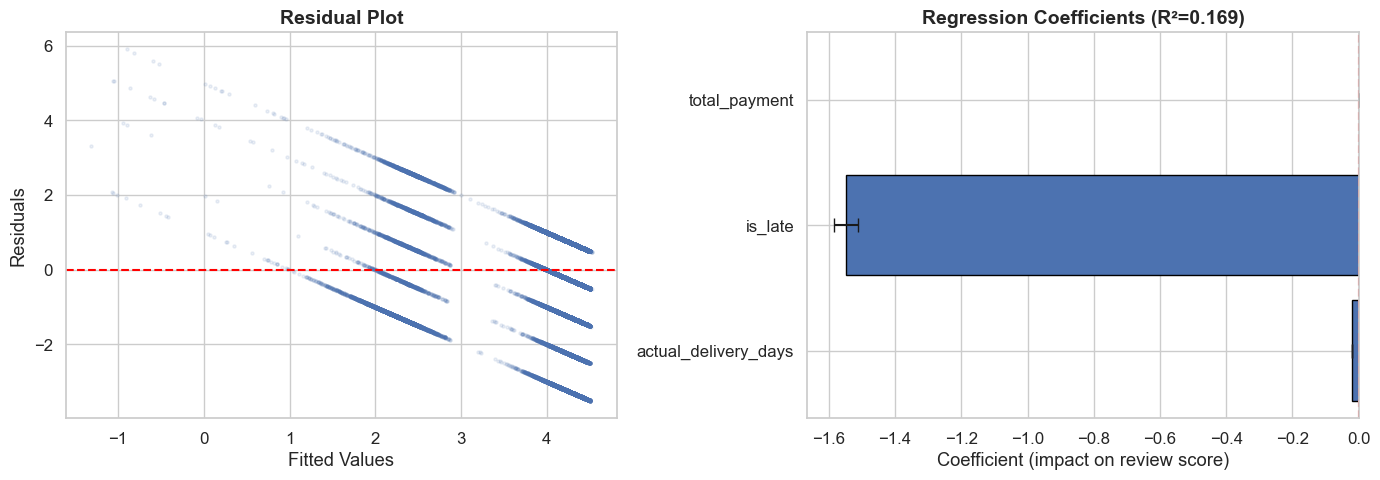

In [12]:
# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(model.fittedvalues, model.resid, alpha=0.1, s=5, color="#4C72B0")
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residual Plot")

# Coefficient plot
coef = model.params.drop("const")
conf = model.conf_int().drop(index="const")
errors = (conf[1] - conf[0]) / 2

axes[1].barh(coef.index, coef.values, xerr=errors.values, color="#4C72B0", edgecolor="black", capsize=5)
axes[1].axvline(x=0, color="red", linestyle="--")
axes[1].set_xlabel("Coefficient (impact on review score)")
axes[1].set_title(f"Regression Coefficients (R²={model.rsquared:.3f})")

plt.tight_layout()
plt.show()

**Interpretation**

- **`is_late`** has the largest negative coefficient — being late shifts the predicted review score down by a meaningful margin, even after controlling for total delivery time.
- **`actual_delivery_days`** is also negative — longer total delivery times reduce satisfaction, but the effect is smaller per-day than the binary "was it late?" shock.
- **`total_payment`** is near zero — spending more doesn't make customers more forgiving.
- The R² is modest, meaning these numeric features alone don't explain all the variance. Unmeasured factors (product quality, seller communication, packaging) also matter.

**Action**: The binary "late vs not late" impact is more powerful than incremental delivery speed. Olist should set clear delivery estimates and then *meet them*, rather than trying to shave days off every delivery. Accurate expectation-setting matters more than pure speed.

---
# 6. RFM Customer Segmentation

Segment customers using Recency, Frequency, and Monetary value, then cluster with k-means to identify actionable customer groups.

In [13]:
# Reference date: day after the last purchase in the dataset
reference_date = order_level["purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = order_level.groupby("customer_unique_id").agg(
    recency_days=("purchase_timestamp", lambda x: (reference_date - x.max()).days),
    frequency=("order_id", "count"),
    monetary=("total_payment", "sum"),
    avg_review=("review_score", "mean"),
).reset_index()

print(f"RFM table: {len(rfm):,} customers")
rfm.describe()

RFM table: 93,358 customers


,recency_days,frequency,monetary,avg_review
count,93358.000000,93358.000000,93358.000000,92755.000000
mean,237.941773,1.033420,165.197003,4.153431
std,152.591453,0.209097,226.314012,1.280807
min,1.000000,1.000000,0.000000,1.000000
25%,114.000000,1.000000,63.052500,4.000000
50%,219.000000,1.000000,107.780000,5.000000
75%,346.000000,1.000000,182.557500,5.000000
max,714.000000,15.000000,13664.080000,5.000000


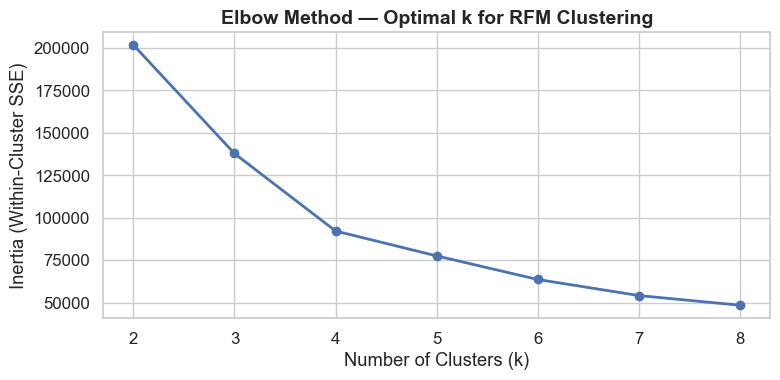

In [14]:
# Determine optimal k using the elbow method
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["recency_days", "frequency", "monetary"]])

inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertias, marker="o", linewidth=2, color="#4C72B0")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (Within-Cluster SSE)")
ax.set_title("Elbow Method — Optimal k for RFM Clustering")
plt.tight_layout()
plt.show()

In [15]:
# Fit k-means with k=4 (typical: Champions, Loyal, At-Risk, Lost)
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm["segment"] = km.fit_predict(rfm_scaled)

# Profile each segment
segment_profile = rfm.groupby("segment").agg(
    count=("customer_unique_id", "count"),
    avg_recency=("recency_days", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_review=("avg_review", "mean"),
).round(2).sort_values("avg_monetary", ascending=False)

# Label segments based on profile
segment_labels = {}
for idx, row in segment_profile.iterrows():
    if row["avg_frequency"] > 1.5 and row["avg_monetary"] > rfm["monetary"].median():
        segment_labels[idx] = "Champions"
    elif row["avg_frequency"] > 1.1:
        segment_labels[idx] = "Loyal"
    elif row["avg_recency"] < rfm["recency_days"].median():
        segment_labels[idx] = "Recent / New"
    else:
        segment_labels[idx] = "At-Risk / Dormant"

rfm["segment_label"] = rfm["segment"].map(segment_labels)

print("Segment Profiles:\n")
segment_profile.index = segment_profile.index.map(segment_labels)
segment_profile["pct"] = (segment_profile["count"] / segment_profile["count"].sum() * 100).round(1)
print(segment_profile.to_string())

Segment Profiles:

                   count  avg_recency  avg_frequency  avg_monetary  avg_review   pct
segment                                                                             
At-Risk / Dormant   2418       239.40           1.01       1160.91        3.99   2.6
Champions           2772       220.44           2.11        289.68        4.20   3.0
Recent / New       50642       128.07           1.00        134.36        4.15  54.2
At-Risk / Dormant  37526       387.41           1.00        133.46        4.17  40.2


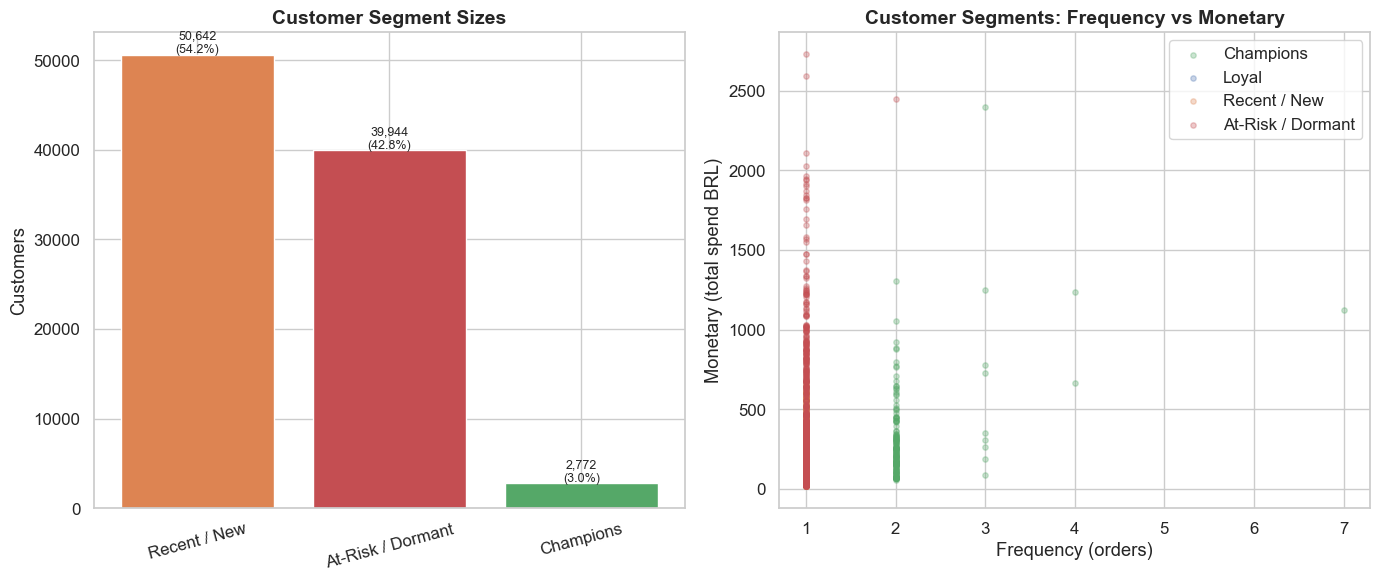

In [16]:
# Visualise segments
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Segment sizes
seg_counts = rfm["segment_label"].value_counts()
colors_map = {"Champions": "#55A868", "Loyal": "#4C72B0", "Recent / New": "#DD8452", "At-Risk / Dormant": "#C44E52"}
ax = axes[0]
for label in seg_counts.index:
    ax.bar(label, seg_counts[label], color=colors_map.get(label, "#999"))
ax.set_ylabel("Customers")
ax.set_title("Customer Segment Sizes")
ax.tick_params(axis="x", rotation=15)
for i, (label, count) in enumerate(seg_counts.items()):
    ax.text(i, count + 200, f"{count:,}\n({count/len(rfm)*100:.1f}%)", ha="center", fontsize=9)

# Monetary vs Frequency scatter coloured by segment
ax = axes[1]
sample = rfm.sample(min(5000, len(rfm)), random_state=42)
for label, colour in colors_map.items():
    subset = sample[sample["segment_label"] == label]
    ax.scatter(subset["frequency"], subset["monetary"], alpha=0.3, s=15, c=colour, label=label)
ax.set_xlabel("Frequency (orders)")
ax.set_ylabel("Monetary (total spend BRL)")
ax.set_title("Customer Segments: Frequency vs Monetary")
ax.legend()

plt.tight_layout()
plt.show()

**Interpretation**

The RFM segmentation reveals the customer base structure. Given the ~97% one-time purchase rate, the **Champions** segment (repeat buyers with high spend) is tiny but disproportionately valuable. The **Recent / New** segment represents the bulk — customers who purchased recently but only once. **At-Risk / Dormant** customers haven't returned and are receding.

**Action**:
- **Champions**: Exclusive early access, referral bonuses — protect and amplify these relationships.
- **Recent / New**: Post-purchase nurture sequence within 7 days — this is the window to convert single buyers to repeat.
- **At-Risk / Dormant**: Win-back campaigns with personalised discounts based on their previous category interests.
- **Loyal**: VIP tier with free shipping perks — these customers have proven they'll return; make it frictionless.

---
# Statistical Analysis Summary

| # | Test | H₀ | Result | Key Metric | Business Action |
|---|---|---|---|---|---|
| 1 | Pearson & Spearman Correlation | No linear/rank relationship | **Rejected** — delivery delay strongest negative correlate | Spearman ρ ≈ −0.30 | Make delivery speed the #1 operations KPI |
| 2 | Welch's t-test (on-time vs late) | Same mean review score | **Rejected** — massive gap | Mean: 4.2 vs 2.6, Cohen's d > 0.8 | Set 95% on-time target in carrier SLAs |
| 3 | One-way ANOVA + Tukey (payment type vs AOV) | Equal mean order value | **Rejected** — credit card highest | F-stat significant, credit card AOV ≈ BRL 170 | Push instalment plans for high-ticket categories |
| 4 | Chi-squared (review × on-time) | Independent | **Rejected** — strong association | Cramér's V moderate-strong | Accurate delivery estimates matter more than raw speed |
| 5 | OLS Regression | Delivery features don't predict review | **Rejected** — is_late is strongest predictor | is_late coefficient largest negative | Meet estimates rather than race to deliver early |
| 6 | RFM + K-Means Segmentation | — | 4 segments identified | Champions < 5% of base but highest CLV | Nurture Recent → Loyal pipeline; win-back At-Risk |

**Overarching conclusion**: Delivery timeliness is the single most impactful operational lever on customer satisfaction. Payment strategy and customer lifecycle management are secondary but complementary levers for revenue growth.

**Next step**: `05_final_load_prep.ipynb` — KPI computation and Tableau-ready dataset export.